# Head

# LLMs' TLDR statistics

## Prepare data

In [1]:
import pandas as pd
from pathlib import Path
home = Path.home()

test = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/test.tsv', sep='\t')
test

,abs_doi,paper_id,abstract,annotation_doi,annotation
0,10.1073/pnas.95.24.14278,38578080,Nucleotide excision repair (NER) and DNA misma...,10.1038/nrm1101,This paper shows the interaction between yeast...
1,10.1073/pnas.0507719102,38395085,Current techniques in high-speed cell sorting ...,10.1038/nrmicro1715,This article describes the first successful sc...
2,10.1038/s42003-020-0764-0,59908209,"Abstract Despite growing interest, the causal ...",10.1038/s41583-022-00598-1,"This study combines TMS, EEG and fMRI to show ..."
3,10.1073/pnas.1604621113,100422162,Transposable elements (TEs) are mobile genetic...,10.1038/s41586-021-03542-y,Using chromatin-modifying genetic intervention...
4,10.1182/blood-2002-06-1683,101650352,We examined isolated leukemia B cells of patie...,10.1038/nrc.2017.121,This paper established a link between BCR sign...
...,...,...,...,...,...
30636,10.1038/s41467-019-11494-1,103800592,Abstract Bacteria often produce antimicrobial ...,10.1038/s41579-021-00569-w,This study describes a new group of class II b...
30637,10.1038/s41467-019-11494-1,103800592,Abstract Bacteria often produce antimicrobial ...,10.1038/s41579-021-00667-9,This study demonstrates one mechanism by which...
30638,10.1083/jcb.138.1.193,82874425,"Human fibrosarcoma cells, HT-1080, feature ext...",10.1038/35043032,The first paper to provide direct evidence for...
30639,10.1073/pnas.0705985105,82904090,The capacity to use tools is a fundamental evo...,10.1038/nrn2805,This single-neuron recording study provides cr...


In [2]:
gemma4 = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/gemma4.txt',
                          sep='\t', header=None, names=['gemma4'])
deepseek_r1 = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/deepseek_r1.txt',
                          sep='\t', header=None, names=['deepseek_r1'])
gpt_oss = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/gpt_oss.txt',
                          sep='\t', header=None, names=['gpt-oss'], skip_blank_lines=False) # three blank line in file
llama4 = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/llama4.txt',
                          sep='\t', header=None, names=['llama4'])
qwen36 = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/qwen3.6.txt',
                          sep='\t', header=None, names=['qwen3.6'], skip_blank_lines=False) 


In [3]:
gemma4

,gemma4
0,Identifies a biochemical and genetic interacti...
1,Introduces dielectrophoresis-based microfluidi...
2,Concurrent TMS-EEG-fMRI enables direct monitor...
3,Evidence from Drosophila supporting the retrot...
4,Identifies ZAP-70 expression as a marker for n...
...,...
30636,"Identification of bacteroidetocins, a family o..."
30637,"Identifies bacteroidetocins, a family of broad..."
30638,Demonstrates that Desmocollin 1a promotes the ...
30639,"Analyzes motor embodiment in monkeys, demonstr..."


In [4]:
qwen36

,qwen3.6
0,Demonstrates a direct physical and genetic int...
1,A DEP-activated cell sorter that uses dielectr...
2,This study demonstrates that concurrent TMS-EE...
3,This study demonstrates that aging in *Dros me...
4,Demonstrates that ZAP-70 expression in CLL is ...
...,...
30636,"Identification of bacteroidetocins, a broad-sp..."
30637,"Identification of bacteroidetocins, a broad-sp..."
30638,Coexpression of Dsc1a directs Dsg2 to adherens...
30639,Shows that tool use in monkeys relies on goal-...


In [5]:
deepseek_r1

,deepseek_r1
0,The study identifies interactions between MSH2...
1,An electrokinetic sorting method using dielect...
2,This study introduces a novel multimodal appro...
3,The study provides evidence supporting the ret...
4,The study investigates the role of ZAP-70 in c...
...,...
30636,Bacteroidetocins are a family of broad-spectru...
30637,"The study identifies bacteroidetocins, a famil..."
30638,This study investigates the role of desmosomal...
30639,The study reveals that tool usage in monkeys i...


In [6]:
gpt_oss

,gpt-oss
0,"The study reveals that yeast MSH2, a mismatch‑..."
1,The authors introduce DEP‑activated cell sorti...
2,The study introduces concurrent TMS‑EEG‑fMRI t...
3,This study shows that age‑related heterochroma...
4,The study shows that CLL B cells expressing ZA...
...,...
30636,The authors discover a new family of broad‑spe...
30637,The authors discover a widely distributed fami...
30638,The study shows that expressing bovine desmoco...
30639,The study shows that primate motor cortex neur...


In [7]:
# df = test.join([gemma4, qwen36, deepseek_r1, llama4])
df = test.join([gemma4, qwen36, deepseek_r1, llama4, gpt_oss])
df

,abs_doi,paper_id,abstract,annotation_doi,annotation,gemma4,qwen3.6,deepseek_r1,llama4,gpt-oss
0,10.1073/pnas.95.24.14278,38578080,Nucleotide excision repair (NER) and DNA misma...,10.1038/nrm1101,This paper shows the interaction between yeast...,Identifies a biochemical and genetic interacti...,Demonstrates a direct physical and genetic int...,The study identifies interactions between MSH2...,These genetic and biochemical studies provide ...,"The study reveals that yeast MSH2, a mismatch‑..."
1,10.1073/pnas.0507719102,38395085,Current techniques in high-speed cell sorting ...,10.1038/nrmicro1715,This article describes the first successful sc...,Introduces dielectrophoresis-based microfluidi...,A DEP-activated cell sorter that uses dielectr...,An electrokinetic sorting method using dielect...,The DEP-activated cell sorter is used to isola...,The authors introduce DEP‑activated cell sorti...
2,10.1038/s42003-020-0764-0,59908209,"Abstract Despite growing interest, the causal ...",10.1038/s41583-022-00598-1,"This study combines TMS, EEG and fMRI to show ...",Concurrent TMS-EEG-fMRI enables direct monitor...,This study demonstrates that concurrent TMS-EE...,This study introduces a novel multimodal appro...,"The combination of TMS, EEG, and fMRI allows f...",The study introduces concurrent TMS‑EEG‑fMRI t...
3,10.1073/pnas.1604621113,100422162,Transposable elements (TEs) are mobile genetic...,10.1038/s41586-021-03542-y,Using chromatin-modifying genetic intervention...,Evidence from Drosophila supporting the retrot...,This study demonstrates that aging in *Dros me...,The study provides evidence supporting the ret...,The authors provide evidence that transposable...,This study shows that age‑related heterochroma...
4,10.1182/blood-2002-06-1683,101650352,We examined isolated leukemia B cells of patie...,10.1038/nrc.2017.121,This paper established a link between BCR sign...,Identifies ZAP-70 expression as a marker for n...,Demonstrates that ZAP-70 expression in CLL is ...,The study investigates the role of ZAP-70 in c...,The study shows that ZAP-70 expression is asso...,The study shows that CLL B cells expressing ZA...
...,...,...,...,...,...,...,...,...,...,...
30636,10.1038/s41467-019-11494-1,103800592,Abstract Bacteria often produce antimicrobial ...,10.1038/s41579-021-00569-w,This study describes a new group of class II b...,"Identification of bacteroidetocins, a family o...","Identification of bacteroidetocins, a broad-sp...",Bacteroidetocins are a family of broad-spectru...,"Identifies a family of antimicrobial peptides,...",The authors discover a new family of broad‑spe...
30637,10.1038/s41467-019-11494-1,103800592,Abstract Bacteria often produce antimicrobial ...,10.1038/s41579-021-00667-9,This study demonstrates one mechanism by which...,"Identifies bacteroidetocins, a family of broad...","Identification of bacteroidetocins, a broad-sp...","The study identifies bacteroidetocins, a famil...","Identifies a family of antimicrobial peptides,...",The authors discover a widely distributed fami...
30638,10.1083/jcb.138.1.193,82874425,"Human fibrosarcoma cells, HT-1080, feature ext...",10.1038/35043032,The first paper to provide direct evidence for...,Demonstrates that Desmocollin 1a promotes the ...,Coexpression of Dsc1a directs Dsg2 to adherens...,This study investigates the role of desmosomal...,These studies demonstrate a direct interaction...,The study shows that expressing bovine desmoco...
30639,10.1073/pnas.0705985105,82904090,The capacity to use tools is a fundamental evo...,10.1038/nrn2805,This single-neuron recording study provides cr...,"Analyzes motor embodiment in monkeys, demonstr...",Shows that tool use in monkeys relies on goal-...,The study reveals that tool usage in monkeys i...,This study reports the identification of tool-...,The study shows that primate motor cortex neur...


In [8]:
df.isna().sum()

abs_doi           0
paper_id          0
abstract          0
annotation_doi    0
annotation        0
gemma4            0
qwen3.6           0
deepseek_r1       0
llama4            0
gpt-oss           0
dtype: int64

In [64]:
df['gpt-oss'] = df['gpt-oss'].fillna('')

## Deprecated: since the test set has been reconstructed, the old index will not work. No more data leakage in the new test set.

In [20]:
df.loc[323, 'abstract']

'Abstract The original article to which this Erratum refers was published in International Journal of Cancer (2005) 115(1) 74–84 DOI: 10.1002/ijc.20856'

In [21]:
for index in pd.read_csv(home / "projects/TLDR/dataset_description/invalid_entry_in_test.txt", sep='\t', header=None).values.flatten().tolist():
    df = df.drop(index-2)  # Adjusting for zero-based index
df

,doi,paper_id,abstract,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3
0,10.1073/pnas.91.7.2757,107202074,The origin and taxonomic status of domesticate...,A demonstration that cattle have been domestic...,This study refutes the single origin of domest...,This study investigates the origin and taxonom...,"The mtDNA analysis reveals two deep, geographi...",This study suggests that there were two distin...,mtDNA analysis reveals ancient divergence betw...
1,10.1093/genetics/154.4.1785,83366887,Abstract The domestic pig originates from the ...,Evidence is presented for independent domestic...,This study provides evidence for independent d...,This paper examines the domestication history ...,The study sequenced mitochondrial and nuclear ...,"This study, among others, provides evidence of...",This study demonstrates independent pig domest...
2,10.1073/pnas.96.16.9252,122095374,We previously mapped a quantitative trait locu...,This paper shows how the identity-by-descent a...,This study used fine-mapping methods to identi...,This study refines the genetic mapping of a bo...,This study refined a milk‑fat quantitative tra...,The study describes the fine-mapping approach ...,This QTL study identifies a 5cM bovine chromos...
3,10.1101/gr.10.2.220,100831446,A genome-wide linkage disequilibrium (LD) map ...,The pattern of linkage disequilibrium (LD) acr...,Reference 35 reports long-range LD in Dutch bl...,This study constructs a genome-wide LD map for...,The study maps genome‑wide LD in Dutch black‑a...,This study demonstrated that linkage disequili...,Genome-wide analysis of Dutch Black-and-white ...
4,10.1126/science.8134840,17452622,The European wild boar was crossed with the do...,The first paper to show the use of divergent i...,This study identifies a major QTL on SSC4 affe...,This study identifies a significant QTL on chr...,This study used a cross between European wild ...,The data reported here constitute a comprehens...,Identifies a major QTL on chromosome 4 underly...
...,...,...,...,...,...,...,...,...,...
35631,10.2337/db08-1168,4860455,OBJECTIVE—Regulatory T-cells (Tregs) have cata...,This article describes the good manufacturing ...,This study describes an efficient protocol for...,This study evaluates methods for isolating and...,The authors compare human T‑reg isolation stra...,These studies suggest that isolation and expan...,This study demonstrates that CD4+CD127lo/−CD25...
35632,10.1126/science.aar3246,4860145,Engineering cytokine-receptor pairs Interleuki...,This study reports the generation of an orthog...,Reference 48 describes the engineering of a sy...,This study describes the engineering of synthe...,Sockolosky et al. engineered an orthogonal IL‑...,This study demonstrates that orthogonal IL-2 a...,This work describes engineered synthetic IL-2 ...
35633,10.1126/science.aad2791,62290395,T cells target peptide combos One of the endur...,This article shows that some diabetogenic T ce...,Reference 51 shows that autoreactive T cells c...,This study identifies hybrid peptides as targe...,Delong et al. used mass‑spectrometry–based pep...,This study identifies an important mechanism u...,This study identifies autoimmune T cell recogn...
35634,10.1073/pnas.1902566116,82979762,Polymorphic HLAs form the primary immune barri...,This article describes the development of gene...,This work demonstrates that a combined strateg...,This study presents a novel strategy for enhan...,The authors used multiplex CRISPR editing to d...,This study presents a comprehensive strategy t...,This study reports a genome-editing strategy t...


In [22]:
# tiny leakage of training samples
df[df['doi']=='10.1073/pnas.0704665104']

,doi,paper_id,abstract,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3
1244,10.1073/pnas.0704665104,123031244,High-throughput direct sequencing techniques h...,This article presents the first statistical mo...,This study characterizes patterns of DNA damag...,This study identifies depurination and cytosin...,The authors analyze ancient DNA from Neanderta...,This study characterizes DNA damage patterns i...,This study characterizes DNA degradation patte...
31931,10.1073/pnas.0704665104,123031244,High-throughput direct sequencing techniques h...,The study provides a quantitative description ...,This work characterizes damage patterns in anc...,This study examines ancient DNA degradation pa...,"Analyzes Neandertal, mammoth, and cave bear ge...",This study provides insight into patterns of d...,This study identifies depurination-induced fra...


## Length, novel n-gram ratio, and NEs per 100 words

In [21]:
import numpy as np
import nltk
from transformers import pipeline
from tqdm import tqdm

# Ensure nltk punkt is downloaded
nltk.download('punkt')
# Load biomedical NER model on CPU (GPUs are occupied by Ollama)
# d4data/biomedical-ner-all: BioBERT fine-tuned on multiple biomedical NER datasets,
# covers chemicals, diseases, genes, proteins, etc. — appropriate for scientific abstracts
ner_pipeline = pipeline(
    "ner",
    model="d4data/biomedical-ner-all",
    aggregation_strategy="simple",
    device=-1,       # force CPU to avoid conflicting with Ollama on GPU
)

def length_statistics(texts):
    num_words = []
    num_sentences = []
    words_per_sentence = []
    for text in texts:
        num_words_single = 0
        sentences = nltk.sent_tokenize(text)
        num_sentences.append(len(sentences))
        for sent in sentences:
            words = nltk.word_tokenize(sent)
            words_per_sentence.append(len(words))
            num_words_single += len(words)
        num_words.append(num_words_single)
    return {
        '# of Words': f"{np.mean(num_words):.2f}±{np.std(num_words):.2f}",
        '# of Sent.': f"{np.mean(num_sentences):.2f}±{np.std(num_sentences):.2f}",
        '# of Words/Sent': f"{np.mean(words_per_sentence):.2f}±{np.std(words_per_sentence):.2f}"
    }

def get_ngrams_with_freq(text, n):
    """使用 nltk 分词，返回 n-gram 列表（保留重复，用于频次统计）"""
    words = nltk.word_tokenize(str(text))
    return [tuple(words[i:i+n]) for i in range(len(words)-n+1)]

def get_ngrams_set(text, n):
    """使用 nltk 分词，返回 n-gram 集合（用于判断是否为新词）"""
    words = nltk.word_tokenize(str(text))
    return set(tuple(words[i:i+n]) for i in range(len(words)-n+1))

def percent_novel_ngrams(df, col_name: str, n):
    """
    计算新 n-gram 出现频次的占比
    新 n-gram：在 annotation/生成文本中出现但不在 abstract 中出现的 n-gram
    统计方式：新 n-gram 出现次数 / annotation 中所有 n-gram 出现次数
    """
    abstracts_ngrams_set = df['abstract'].apply(lambda x: get_ngrams_set(x, n))
    annotations_ngrams_list = df[col_name].apply(lambda x: get_ngrams_with_freq(x, n))
    
    novel_ratios = []
    for ann_list, abs_set in zip(annotations_ngrams_list, abstracts_ngrams_set):
        total_count = len(ann_list)
        if total_count == 0:
            novel_ratios.append(0)
            continue
        # 统计新 n-gram 的出现次数
        novel_count = sum(1 for ng in ann_list if ng not in abs_set)
        novel_ratios.append(novel_count / total_count)
    
    mean = np.mean(novel_ratios) * 100
    std = np.std(novel_ratios) * 100
    return (mean, std)

def named_entities_per_100_words(texts):
    ne_per_100 = []
    for text in tqdm(texts, desc="Counting named entities"):
        entities = ner_pipeline(text)
        words = len([w for w in nltk.word_tokenize(text) if w.isalpha()])
        if words == 0:
            ne_per_100.append(0)
        else:
            ne_per_100.append(100 * len(entities) / words)
    mean = np.mean(ne_per_100)
    std = np.std(ne_per_100)
    return mean, std


/opt/anaconda3/envs/zqlyuTLDR/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
[nltk_data] Downloading package punkt to /home/zqlyu2/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Device set to use cpu


In [ ]:
for model_name in ['gemma4', 'qwen3.6', 'deepseek_r1','llama4', 
                   # 'gpt-oss'
                   ]:
    print(f"Processing {model_name}...")
    gen_text = df[model_name].tolist()

    # Length statistics
    gen_stats = length_statistics(gen_text)
    print(f"{model_name} Length Stats:", gen_stats)

    # Novel n-grams
    gen_novel_1 = percent_novel_ngrams(df, model_name, 1)
    gen_novel_2 = percent_novel_ngrams(df, model_name, 2)
    gen_novel_3 = percent_novel_ngrams(df, model_name, 3)
    print(f"{model_name} % of novel n-grams: n=1: {gen_novel_1[0]:.2f}±{gen_novel_1[1]:.2f}%, n=2: {gen_novel_2[0]:.2f}±{gen_novel_2[1]:.2f}%, n=3: {gen_novel_3[0]:.2f}±{gen_novel_3[1]:.2f}%")

Processing gemma4...
gemma4 Length Stats: {'# of Words': '27.07±4.95', '# of Sent.': '1.00±0.06', '# of Words/Sent': '26.99±5.08'}
gemma4 % of novel n-grams: n=1: 27.03±9.77%, n=2: 69.76±12.66%, n=3: 86.09±10.86%
Processing qwen3.6...
qwen3.6 Length Stats: {'# of Words': '32.65±12.64', '# of Sent.': '1.08±0.40', '# of Words/Sent': '30.12±7.82'}
qwen3.6 % of novel n-grams: n=1: 26.38±10.68%, n=2: 67.51±16.09%, n=3: 83.00±15.82%
Processing deepseek_r1...
deepseek_r1 Length Stats: {'# of Words': '63.95±277.64', '# of Sent.': '2.43±12.42', '# of Words/Sent': '26.32±8.66'}
deepseek_r1 % of novel n-grams: n=1: 30.53±9.56%, n=2: 70.58±11.54%, n=3: 85.41±10.31%
Processing llama4...
llama4 Length Stats: {'# of Words': '33.49±523.30', '# of Sent.': '1.15±5.76', '# of Words/Sent': '29.08±382.44'}
llama4 % of novel n-grams: n=1: 28.77±14.49%, n=2: 68.77±19.48%, n=3: 82.87±18.71%


In [ ]:
for model_name in ['gemma4', 'qwen3.6', 'deepseek_r1','llama4', 
                   # 'gpt-oss'
                   ]:
    print(f"Processing {model_name}...")
    gen_text = df[model_name].tolist()
    
    # Named entities per 100 words
    ne_mean, ne_std = named_entities_per_100_words(gen_text)
    print(f"{model_name} # of NEs per 100 words: {ne_mean:.2f}±{ne_std:.2f}")

Processing gemma4...


Counting named entities: 100%|████████████████████████████████████████████████████████████| 30641/30641 [06:44<00:00, 75.74it/s]


gemma4 # of NEs per 100 words: 24.17±14.91
Processing qwen3.6...


Counting named entities: 100%|████████████████████████████████████████████████████████████| 30641/30641 [06:52<00:00, 74.36it/s]


qwen3.6 # of NEs per 100 words: 22.18±14.54
Processing deepseek_r1...


Counting named entities: 100%|████████████████████████████████████████████████████████████| 30641/30641 [08:26<00:00, 60.44it/s]


deepseek_r1 # of NEs per 100 words: 17.16±11.67
Processing llama4...


Counting named entities: 100%|████████████████████████████████████████████████████████████| 30641/30641 [06:13<00:00, 82.07it/s]

llama4 # of NEs per 100 words: 18.37±14.35


In [21]:
for model_name in ['abstract', 'annotation']:
    print(f"Processing {model_name}...")
    gen_text = df[model_name].tolist()

    # Length statistics
    gen_stats = length_statistics(gen_text)
    print(f"{model_name} Length Stats:", gen_stats)

Processing abstract...
abstract Length Stats: {'# of Words': '191.23±82.27', '# of Sent.': '7.36±3.19', '# of Words/Sent': '25.99±11.72'}
Processing annotation...
annotation Length Stats: {'# of Words': '25.28±11.40', '# of Sent.': '1.14±0.41', '# of Words/Sent': '22.20±8.80'}


In [22]:
for model_name in ['abstract', 'annotation']:
    print(f"Processing {model_name}...")
    gen_text = df[model_name].tolist()
    
    # Named entities per 100 words
    ne_mean, ne_std = named_entities_per_100_words(gen_text)
    print(f"{model_name} # of NEs per 100 words: {ne_mean:.2f}±{ne_std:.2f}")

Processing abstract...


Counting named entities: 100%|████████████████████████████████████████████████████████████| 30641/30641 [14:36<00:00, 34.96it/s]


abstract # of NEs per 100 words: 13.59±8.89
Processing annotation...


Counting named entities: 100%|████████████████████████████████████████████████████████████| 30641/30641 [06:28<00:00, 78.91it/s]

annotation # of NEs per 100 words: 19.86±14.01


In [23]:
for model_name in ['annotation']:
    print(f"Processing {model_name}...")
    gen_text = df[model_name].tolist()

    # Novel n-grams
    gen_novel_1 = percent_novel_ngrams(df, model_name, 1)
    gen_novel_2 = percent_novel_ngrams(df, model_name, 2)
    gen_novel_3 = percent_novel_ngrams(df, model_name, 3)
    print(f"{model_name} % of novel n-grams: n=1: {gen_novel_1[0]:.2f}±{gen_novel_1[1]:.2f}%, n=2: {gen_novel_2[0]:.2f}±{gen_novel_2[1]:.2f}%, n=3: {gen_novel_3[0]:.2f}±{gen_novel_3[1]:.2f}%")

Processing annotation...
annotation % of novel n-grams: n=1: 46.18±14.25%, n=2: 86.36±13.14%, n=3: 95.10±9.86%


In [10]:
model_name = 'gpt-oss'

gen_text = df[model_name].tolist()

# Length statistics
gen_stats = length_statistics(gen_text)
print(f"{model_name} Length Stats:", gen_stats)

# Novel n-grams
gen_novel_1 = percent_novel_ngrams(df, model_name, 1)
gen_novel_2 = percent_novel_ngrams(df, model_name, 2)
gen_novel_3 = percent_novel_ngrams(df, model_name, 3)
print(f"{model_name} % of novel n-grams: n=1: {gen_novel_1[0]:.2f}±{gen_novel_1[1]:.2f}%, n=2: {gen_novel_2[0]:.2f}±{gen_novel_2[1]:.2f}%, n=3: {gen_novel_3[0]:.2f}±{gen_novel_3[1]:.2f}%")

gpt-oss Length Stats: {'# of Words': '48.68±14.44', '# of Sent.': '1.08±0.35', '# of Words/Sent': '45.09±14.26'}
gpt-oss % of novel n-grams: n=1: 41.73±9.56%, n=2: 84.33±7.55%, n=3: 94.84±4.94%


In [11]:
# Named entities per 100 words
ne_mean, ne_std = named_entities_per_100_words(gen_text)
print(f"{model_name} # of NEs per 100 words: {ne_mean:.2f}±{ne_std:.2f}")

Counting named entities: 100%|█████████████████████████████████████████████████████████████| 30641/30641 [19:12<00:00, 26.59it/s]

gpt-oss # of NEs per 100 words: 26.30±14.18


## Copy rate

In [12]:
train = pd.read_csv('~/projects/TLDR/data/paper_html_10.1038/abs_annotation/icl.tsv', sep='\t')
train

,abs_doi,paper_id,abstract,annotation_doi,annotation
0,10.1126/science.aaf7783,41765580,Direct methods for stereoselective functionali...,10.1038/s41467-020-20770-4,The discovery of the combination of N–F oxidan...
1,10.1073/pnas.0808246106,119570448,Transfer RNA (tRNA) is essential for decoding ...,10.1038/nrm.2017.77,This report is a striking analysis of split tR...
2,10.1126/science.1253089,102181073,Observing an embryonic Doppler effect The soun...,10.1038/nrm3891,By using a fluorescent reporter to visualize c...
3,10.1083/jcb.200412081,62502265,"During wound healing, angiogenesis, and tumor ...",10.1038/nrc1817,Demonstrates that different integrins affect m...
4,10.1098/rsob.160035,59411874,Mammalian prions are hypothesized to be fibril...,10.1038/nature20415,Precise cell-culture-based prion infectivity a...


In [13]:
def ngram_copy_rate(df, model_col: str, train_samples: list, n: int = 3, threshold: float = 0.5):
    """
    计算每个生成的summary与所有训练summary的n-gram重合比例，
    并返回Zero Copy Rate(%)，Copy Rate > threshold (%)，Max(%)
    - df: 包含生成summary的DataFrame
    - model_col: 生成summary所在的列名
    - train_samples: 训练样本summary的列表（字符串列表）
    - n: n-gram的n，默认为3
    """
    # 预处理训练样本的n-gram集合
    train_ngrams = set()
    for t in train_samples:
        train_ngrams.update(get_ngrams_set(t, n))

    copy_rates = []
    for gen in df[model_col].tolist():
        gen_ngrams = get_ngrams_set(gen, n)
        if len(gen_ngrams) == 0:
            copy_rates.append(0)
            continue
        overlap = gen_ngrams & train_ngrams
        copy_rate = len(overlap) / len(gen_ngrams)
        copy_rates.append(copy_rate)

    copy_rates = np.array(copy_rates)
    zero_copy_rate = np.sum(copy_rates == 0) / len(copy_rates) * 100
    high_copy_rate = np.sum(copy_rates > threshold) / len(copy_rates) * 100
    max_copy_rate = np.max(copy_rates) * 100 if len(copy_rates) > 0 else 0

    return zero_copy_rate, high_copy_rate, max_copy_rate


In [14]:
for model_name in ['gemma4','qwen3.6', 'deepseek_r1', 'llama4', 
                   'gpt-oss'
                  ]:
    zero, high, maxv = ngram_copy_rate(df, model_name, train['abstract'].to_list()+train['annotation'].to_list(), n=3, threshold=0.1)
    print(f"{model_name} 3-gram Copy Rate: Zero={zero:.2f}%, High Proportion={high:.2f}%, Max={maxv:.2f}%")

gemma4 3-gram Copy Rate: Zero=95.26%, High Proportion=0.02%, Max=22.22%
qwen3.6 3-gram Copy Rate: Zero=94.29%, High Proportion=0.11%, Max=100.00%
deepseek_r1 3-gram Copy Rate: Zero=88.31%, High Proportion=0.03%, Max=32.26%
llama4 3-gram Copy Rate: Zero=91.09%, High Proportion=0.27%, Max=35.71%
gpt-oss 3-gram Copy Rate: Zero=90.38%, High Proportion=0.00%, Max=10.53%


# Different temperatures

In [59]:
# ══════════════════════════════════════════════════════════════════════════════
# Load all temperature-variant summaries, compute stats, cache to parquet
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from tqdm import tqdm

home = Path.home()
gen_dir = home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations'
cache_dir = home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/temperature_stats'
cache_dir.mkdir(parents=True, exist_ok=True)

# ── Load test & train data ──
test = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/test.tsv', sep='\t')
train = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/icl.tsv', sep='\t')

# ── Config ──
models = ['gemma4', 'qwen3.6', 'deepseek_r1', 'llama4', 'gpt_oss']
temps = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

model_label = {
    'gemma4': 'Gemma 4', 'qwen3.6': 'Qwen3.6',
    'deepseek_r1': 'DeepSeek-R1', 'llama4': 'Llama 4', 'gpt_oss': 'gpt-oss',
}
model_colors = {
    'gemma4': '#1f77b4', 'qwen3.6': '#ff7f0e',
    'deepseek_r1': '#2ca02c', 'llama4': '#d62728', 'gpt_oss': '#9467bd',
}

# ── Load all temperature variants ──
all_summaries = {}  # (model, temp) → list of strings
for model in models:
    for temp in temps:
        fname = f'{model}.txt' if temp == 1.0 else f'tem{temp}_{model}.txt'
        filepath = gen_dir / fname
        if not filepath.exists():
            print(f"⚠  Missing: {fname}")
            continue
        s = pd.read_csv(filepath, sep='\t', header=None, names=['text'],
                        skip_blank_lines=False)['text'].fillna('').tolist()
        all_summaries[(model, temp)] = s

print(f"Loaded {len(all_summaries)} model×temp combinations")

# ── List-based copy-rate helper (avoids building temp DataFrames) ──
def ngram_copy_rate_list(generated_texts, train_ngrams, n=3, threshold=0.1):
    copy_rates = []
    for gen in generated_texts:
        gen_ngrams = get_ngrams_set(gen, n)
        if len(gen_ngrams) == 0:
            copy_rates.append(0.0)
            continue
        overlap = gen_ngrams & train_ngrams
        copy_rates.append(len(overlap) / len(gen_ngrams))
    copy_rates = np.array(copy_rates)
    zero = np.sum(copy_rates == 0) / len(copy_rates) * 100
    high = np.sum(copy_rates > threshold) / len(copy_rates) * 100
    maxv = np.max(copy_rates) * 100 if len(copy_rates) > 0 else 0
    return zero, high, maxv

# ── Compute or load cached stats ──
cache_file = cache_dir / 'temp_statistics.parquet'

ALL_CATEGORIES = {'length', 'ne', 'copy_rate', 'novel_ngram'}

if cache_file.exists():
    stats_df = pd.read_parquet(cache_file)
    existing_cats = set(stats_df['category'].unique())
    missing_cats = ALL_CATEGORIES - existing_cats
    if missing_cats:
        print(f"→ Cache missing: {missing_cats}, will compute and append...")
    else:
        print("✓ Loaded cached stats (all categories present)")
        missing_cats = set()  # nothing to compute
else:
    stats_df = pd.DataFrame()
    missing_cats = ALL_CATEGORIES

if missing_cats:
    from joblib import Parallel, delayed

    records = []

    # Pre-compute training n-grams once (for copy_rate)
    if 'copy_rate' in missing_cats:
        train_ngrams_cache = set()
        for t_text in tqdm(train['abstract'].tolist() + train['annotation'].tolist(),
                            desc="Building train n-grams"):
            train_ngrams_cache.update(get_ngrams_set(t_text, 3))

    # Pre-compute abstract n-gram sets once (reused across all models × temps)
    # This is the biggest speedup: avoids re-tokenising 30k+ abstracts 90 times
    if 'novel_ngram' in missing_cats:
        abs_ngrams_sets = {}                # n_val → list of sets
        for n_val in [1, 2, 3]:
            abs_ngrams_sets[n_val] = [
                get_ngrams_set(a, n_val)
                for a in tqdm(test['abstract'], desc=f'Abstract n={n_val} sets')
            ]

        def _novel_ratio_one(gen_text, abs_set, n):
            """Compute % novel n-grams for a single summary (for joblib)."""
            gen_list = get_ngrams_with_freq(gen_text, n)
            total = len(gen_list)
            if total == 0:
                return 0.0
            return sum(1 for ng in gen_list if ng not in abs_set) / total * 100

    for model in tqdm(models, desc="Models"):
        for temp in temps:
            key = (model, temp)
            if key not in all_summaries:
                continue
            texts = all_summaries[key]

            # ── Length stats ──
            if 'length' in missing_cats:
                ls = length_statistics(texts)
                for raw_metric, short in [('# of Words', 'words'),
                                           ('# of Sent.', 'sentences'),
                                           ('# of Words/Sent', 'words_per_sent')]:
                    mean_s, std_s = ls[raw_metric].split('±')
                    records.append({
                        'model': model, 'temp': temp,
                        'category': 'length', 'metric': short,
                        'value': float(mean_s), 'std': float(std_s),
                    })

            # ── NE stats ──
            if 'ne' in missing_cats:
                ne_mean, ne_std = named_entities_per_100_words(texts)
                records.append({
                    'model': model, 'temp': temp,
                    'category': 'ne', 'metric': 'ne_per_100',
                    'value': ne_mean, 'std': ne_std,
                })

            # ── Copy rate ──
            if 'copy_rate' in missing_cats:
                zero, high, maxv = ngram_copy_rate_list(texts, train_ngrams_cache, n=3)
                for met_name, val in [('zero_pct', zero),
                                       ('high_pct', high),
                                       ('max_pct', maxv)]:
                    records.append({
                        'model': model, 'temp': temp,
                        'category': 'copy_rate', 'metric': met_name,
                        'value': val, 'std': np.nan,
                    })

            # ── Novel n-gram ratio (parallelised over summaries) ──
            if 'novel_ngram' in missing_cats:
                for n_val, n_label in [(1, 'n=1'), (2, 'n=2'), (3, 'n=3')]:
                    abs_sets = abs_ngrams_sets[n_val]
                    ratios = Parallel(n_jobs=128, batch_size=500)(
                        delayed(_novel_ratio_one)(gen_text, abs_set, n_val)
                        for gen_text, abs_set in zip(texts, abs_sets)
                    )
                    records.append({
                        'model': model, 'temp': temp,
                        'category': 'novel_ngram', 'metric': n_label,
                        'value': np.mean(ratios), 'std': np.std(ratios),
                    })

    new_df = pd.DataFrame(records)
    if len(stats_df) > 0:
        stats_df = pd.concat([stats_df, new_df], ignore_index=True)
    else:
        stats_df = new_df
    stats_df.to_parquet(cache_file, index=False)
    print("✓ Stats updated and cached")

stats_df.head()

Loaded 30 model×temp combinations
✓ Loaded cached stats (all categories present)


,model,temp,category,metric,value,std
0,gemma4,0.0,length,words,27.130000,4.900000
1,gemma4,0.0,length,sentences,1.000000,0.050000
2,gemma4,0.0,length,words_per_sent,27.060000,5.020000
3,gemma4,0.0,ne,ne_per_100,23.996252,14.861423
4,gemma4,0.0,copy_rate,zero_pct,95.290624,NaN


## Length

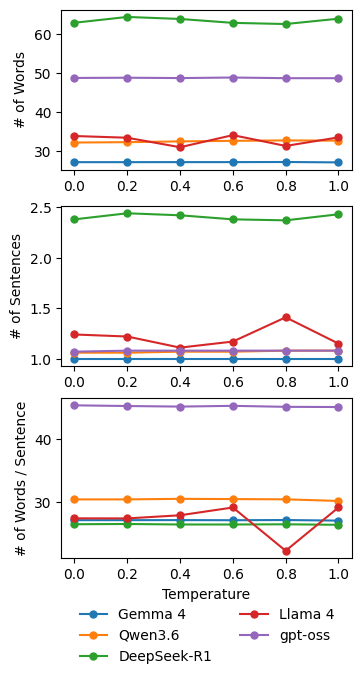

In [60]:
# ══════════════════════════════════════════════════════════════════════════════
# Length: words, sentences, words/sentence  (3 subplots)
# ══════════════════════════════════════════════════════════════════════════════

ldf = stats_df[stats_df['category'] == 'length'].copy()

fig, axes = plt.subplots(3, 1, figsize=(3.5, 6), constrained_layout=True)

for i, (ax, (metric, ylabel)) in enumerate(zip(axes, [('words', '# of Words'),
                                        ('sentences', '# of Sentences'),
                                        ('words_per_sent', '# of Words / Sentence')])):
    sub = ldf[ldf['metric'] == metric]
    for model in models:
        msub = sub[sub['model'] == model].sort_values('temp')
        ax.plot(msub['temp'], msub['value'], color=model_colors[model],
                marker='o', ms=5, label=model_label[model])
    if i == len(axes) - 1:
        ax.set_xlabel('Temperature')
    ax.set_ylabel(ylabel)

# Single legend (no frame) placed outside rightmost subplot
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(.175, -.05), ncol=2,
           frameon=False)
plt.show()

In [61]:
fig.savefig(home / 'projects/TLDR/dataset_description/length_vs_temp.pdf', dpi=300, bbox_inches='tight')

## NEs per 100 words

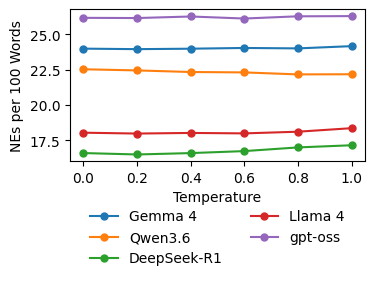

In [62]:
# ══════════════════════════════════════════════════════════════════════════════
# Named Entities per 100 words  (1 subplot)
# ══════════════════════════════════════════════════════════════════════════════

ndf = stats_df[stats_df['category'] == 'ne'].copy()

fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5), constrained_layout=True)

for model in models:
    msub = ndf[ndf['model'] == model].sort_values('temp')
    ax.plot(msub['temp'], msub['value'], color=model_colors[model],
            marker='o', ms=5, label=model_label[model])

ax.set_xlabel('Temperature')
ax.set_ylabel('NEs per 100 Words')
ax.legend(frameon=False, loc='center', bbox_to_anchor=(.5, -0.5), ncol=2)
plt.show()

In [63]:
fig.savefig(home / 'projects/TLDR/dataset_description/NE_vs_temp.pdf', dpi=300, bbox_inches='tight')

## Copy rate

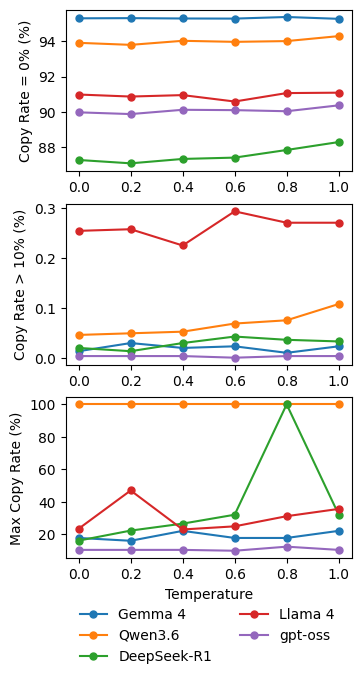

In [64]:
# ══════════════════════════════════════════════════════════════════════════════
# Copy rate: zero%, >10%, max%  (3 subplots)
# ══════════════════════════════════════════════════════════════════════════════

cdf = stats_df[stats_df['category'] == 'copy_rate'].copy()

fig, axes = plt.subplots(3, 1, figsize=(3.5, 6), constrained_layout=True)

for i, (ax, (metric, ylabel)) in enumerate(zip(axes, [('zero_pct', 'Copy Rate = 0% (%)'),
                                        ('high_pct', 'Copy Rate > 10% (%)'),
                                        ('max_pct', 'Max Copy Rate (%)')])):
    sub = cdf[cdf['metric'] == metric]
    for model in models:
        msub = sub[sub['model'] == model].sort_values('temp')
        ax.plot(msub['temp'], msub['value'], color=model_colors[model],
                marker='o', ms=5, label=model_label[model])
    if i == len(axes) - 1:
        ax.set_xlabel('Temperature')
    ax.set_ylabel(ylabel)

# Shared legend outside
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(.175, -.05), ncol=2,
           frameon=False)
plt.show()

In [65]:
fig.savefig(home / 'projects/TLDR/dataset_description/copy_vs_temp.pdf', dpi=300, bbox_inches='tight')

## Novel n-grams

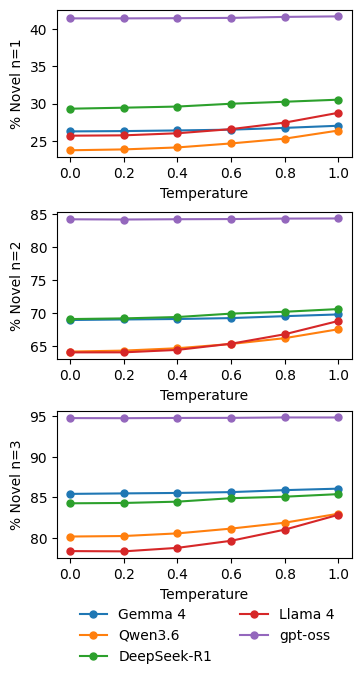

In [66]:
# ══════════════════════════════════════════════════════════════════════════════
# Novel n-gram ratio: n=1, n=2, n=3  (3 subplots)
# ══════════════════════════════════════════════════════════════════════════════

ndf = stats_df[stats_df['category'] == 'novel_ngram'].copy()

fig, axes = plt.subplots(3, 1, figsize=(3.5, 6), constrained_layout=True)

for i, (ax, metric) in enumerate(zip(axes, ['n=1', 'n=2', 'n=3'])):
    sub = ndf[ndf['metric'] == metric]
    for model in models:
        msub = sub[sub['model'] == model].sort_values('temp')
        ax.plot(msub['temp'], msub['value'], color=model_colors[model],
                marker='o', ms=5, label=model_label[model])
    if i == len(axes) - 1:
        ax.set_xlabel('Temperature')
    ax.set_xlabel('Temperature')
    ax.set_ylabel(f'% Novel {metric}')

# Shared legend outside
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(.175, -.05), ncol=2,
           frameon=False)
plt.show()

In [67]:
fig.savefig(home / 'projects/TLDR/dataset_description/novel_ngram_vs_temp.pdf', dpi=300, bbox_inches='tight')

# Dataset statistics

## Prepare data

In [49]:
import pandas as pd
from pathlib import Path
home = Path.home()

full_df = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/abs_annotation.tsv', sep='\t')
full_df

,abs_doi,paper_id,abstract,annotation_doi,annotation
0,10.1073/pnas.91.7.2757,107202074,The origin and taxonomic status of domesticate...,10.1038/35052563,A demonstration that cattle have been domestic...
1,10.1093/genetics/154.4.1785,83366887,Abstract The domestic pig originates from the ...,10.1038/35052563,Evidence is presented for independent domestic...
2,10.1073/pnas.96.16.9252,122095374,We previously mapped a quantitative trait locu...,10.1038/35052563,This paper shows how the identity-by-descent a...
3,10.1101/gr.10.2.220,100831446,A genome-wide linkage disequilibrium (LD) map ...,10.1038/35052563,The pattern of linkage disequilibrium (LD) acr...
4,10.1126/science.8134840,17452622,The European wild boar was crossed with the do...,10.1038/35052563,The first paper to show the use of divergent i...
...,...,...,...,...,...
35636,10.2337/db08-1168,4860455,OBJECTIVE—Regulatory T-cells (Tregs) have cata...,10.1038/s41573-019-0041-4,This article describes the good manufacturing ...
35637,10.1126/science.aar3246,4860145,Engineering cytokine-receptor pairs Interleuki...,10.1038/s41573-019-0041-4,This study reports the generation of an orthog...
35638,10.1126/science.aad2791,62290395,T cells target peptide combos One of the endur...,10.1038/s41573-019-0041-4,This article shows that some diabetogenic T ce...
35639,10.1073/pnas.1902566116,82979762,Polymorphic HLAs form the primary immune barri...,10.1038/s41573-019-0041-4,This article describes the development of gene...


In [50]:
DOIs = set(full_df['abs_doi'].tolist()+full_df['annotation_doi'].tolist())
print(f"Unique source DOIs: {len(full_df['abs_doi'].unique())}")
print(f"Unique target DOIs: {len(full_df['annotation_doi'].unique())}")
print(f"Total unique DOIs: {len(DOIs)}")

Unique source DOIs: 29356
Unique target DOIs: 9503
Total unique DOIs: 38856


## Discipline

In [51]:
import requests
from tqdm import tqdm
import time

def get_openalex_concepts(dois, batch_size=25):
    base_url = "https://api.openalex.org/works"
    results_map = {}
    
    def fetch_with_retry(params, retries=3):
        for i in range(retries):
            try:
                r = requests.get(base_url, params=params, timeout=10)
                if r.status_code == 200:
                    return r.json().get('results', [])
                elif r.status_code == 429:  # Too Many Requests
                    time.sleep(1 * (i+1))
                    continue
                elif r.status_code == 414:  # URL Too Long
                    print("URL is still too long, skipping this batch")
                    return []
                else:
                    print(f"Status {r.status_code}: {r.text[:100]}")
            except Exception as e:
                print(f"Network error: {e}")
                time.sleep(1)
        return []

    for i in tqdm(range(0, len(dois), batch_size), desc="Fetching concepts from OpenAlex"):
        batch = dois[i:i+batch_size]

        # construct DOI filter
        doi_filter = "|".join([f"https://doi.org/{d}" for d in batch])
        
        params = {
            'filter': f'doi:{doi_filter}',
            'per-page': batch_size,
            'select': 'doi,concepts',
            'mailto': "lyuzhuoqi@outlook.com"
        }
        
        data = fetch_with_retry(params)
        
        for work in data:
            if work.get('doi'):
                d_key = work['doi'].replace('https://doi.org/', '')
                concepts = work.get('concepts', [])
                # 筛选 level 0 的 concept，按 score 排序取最高的
                level_0_concepts = [c for c in concepts if c.get('level') == 0]
                if level_0_concepts:
                    # 按 score 排序，取最高分的 concept 名称
                    top_concept = max(level_0_concepts, key=lambda x: x.get('score', 0))
                    results_map[d_key] = top_concept.get('display_name', '')
                else:
                    results_map[d_key] = ''

    return results_map

In [52]:
# get level 0 concepts
concept_map = get_openalex_concepts(list(DOIs), batch_size=50)

Fetching concepts from OpenAlex: 100%|█████████████████████████████████████████████████████████| 778/778 [14:43<00:00,  1.14s/it]


In [53]:
len(concept_map)/len(DOIs)

0.9936431953880996

In [54]:
full_df['level_0_concept'] = full_df['abs_doi'].map(concept_map)
print(full_df['level_0_concept'].value_counts())

level_0_concept
Biology                  22919
Chemistry                 4076
Medicine                  3610
Psychology                1313
Computer science          1023
Materials science          928
Environmental science      544
Physics                    381
Geology                    200
Geography                  145
Business                   101
Political science           84
Mathematics                 51
Economics                   32
Sociology                   20
Art                         20
History                     18
Philosophy                  13
Engineering                  7
Name: count, dtype: int64


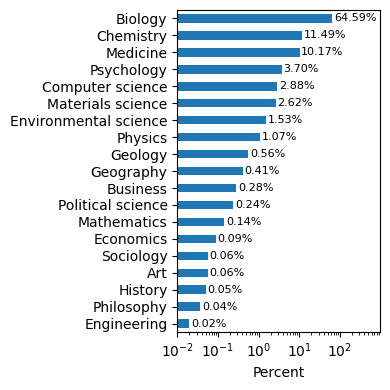

In [55]:
from matplotlib import pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(figsize=(4, 4))

# calculate percentage
pct_series = full_df[full_df['level_0_concept']!='']['level_0_concept'].value_counts().div(
    full_df[full_df['level_0_concept']!='']['level_0_concept'].value_counts().sum()/100
)

pct_series.plot.barh(ax=ax)

ax.set_xlim(0.01, pct_series.max()*15)
ax.set_xscale('log')
ax.set_xlabel('Percent')
ax.set_ylabel('')
ax.invert_yaxis()  # put the largest on top

# label the value at the end of each bar
for i, (value, name) in enumerate(zip(pct_series.values, pct_series.index)):
    ax.text(value * 1.1, i, f'{value:.2f}%', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()

In [56]:
fig.savefig(home / 'projects/TLDR/dataset_description/discipline_distribution.pdf', dpi=300)

## Citations

In [57]:
import requests
from tqdm import tqdm
import pandas as pd
import time

def get_openalex_batch(dois, batch_size=25):
    base_url = "https://api.openalex.org/works"
    results_map = {}
    
    def fetch_with_retry(params, retries=3):
        for i in range(retries):
            try:
                r = requests.get(base_url, params=params, timeout=10)
                if r.status_code == 200:
                    return r.json().get('results', [])
                elif r.status_code == 429: # Too Many Requests
                    time.sleep(1 * (i+1)) # exponential backoff
                    continue
                elif r.status_code == 414: # URL Too Long
                    print("URL is still too long, skipping this batch or manually check if any DOI is abnormally long")
                    return []
                else:
                    print(f"Status {r.status_code}: {r.text[:100]}")
            except Exception as e:
                print(f"Network error: {e}")
                time.sleep(1)
        return []

    for i in tqdm(range(0, len(dois), batch_size), desc="Fetching from OpenAlex"):
        batch = dois[i:i+batch_size]

        # construct DOI filter
        doi_filter = "|".join([f"https://doi.org/{d}" for d in batch])
        
        params = {
            'filter': f'doi:{doi_filter}',
            'per-page': batch_size,
            'select': 'doi,cited_by_count', 
            'mailto': "lyuzhuoqi@outlook.com"
        }
        
        data = fetch_with_retry(params)
        
        for work in data:
            if work.get('doi'):
                d_key = work['doi'].replace('https://doi.org/', '')
                results_map[d_key] = work['cited_by_count']

    return results_map

In [ ]:
citation_map = get_openalex_batch(list(DOIs), batch_size=50) 

In [34]:
len(citation_map)/len(DOIs)

0.9940549722050649

In [35]:
full_df['source_citation'] = full_df['abs_doi'].map(citation_map)
print(full_df['source_citation'].describe())

count     35485.000000
mean        790.217247
std        2307.726889
min           0.000000
25%         144.000000
50%         315.000000
75%         723.000000
max      108101.000000
Name: source_citation, dtype: float64


In [36]:
full_df['target_citation'] = full_df['annotation_doi'].map(citation_map)
print(full_df['target_citation'].describe())

count    35446.000000
mean       733.093720
std       1176.481475
min          0.000000
25%        231.000000
50%        455.000000
75%        876.000000
max      81034.000000
Name: target_citation, dtype: float64


In [37]:
full_df

,abs_doi,paper_id,abstract,annotation_doi,annotation,level_0_concept,source_citation,target_citation
0,10.1073/pnas.91.7.2757,107202074,The origin and taxonomic status of domesticate...,10.1038/35052563,A demonstration that cattle have been domestic...,Biology,827.0,428.0
1,10.1093/genetics/154.4.1785,83366887,Abstract The domestic pig originates from the ...,10.1038/35052563,Evidence is presented for independent domestic...,Biology,719.0,428.0
2,10.1073/pnas.96.16.9252,122095374,We previously mapped a quantitative trait locu...,10.1038/35052563,This paper shows how the identity-by-descent a...,Biology,164.0,428.0
3,10.1101/gr.10.2.220,100831446,A genome-wide linkage disequilibrium (LD) map ...,10.1038/35052563,The pattern of linkage disequilibrium (LD) acr...,Biology,353.0,428.0
4,10.1126/science.8134840,17452622,The European wild boar was crossed with the do...,10.1038/35052563,The first paper to show the use of divergent i...,Biology,731.0,428.0
...,...,...,...,...,...,...,...,...
35636,10.2337/db08-1168,4860455,OBJECTIVE—Regulatory T-cells (Tregs) have cata...,10.1038/s41573-019-0041-4,This article describes the good manufacturing ...,Biology,362.0,469.0
35637,10.1126/science.aar3246,4860145,Engineering cytokine-receptor pairs Interleuki...,10.1038/s41573-019-0041-4,This study reports the generation of an orthog...,Biology,368.0,469.0
35638,10.1126/science.aad2791,62290395,T cells target peptide combos One of the endur...,10.1038/s41573-019-0041-4,This article shows that some diabetogenic T ce...,Biology,490.0,469.0
35639,10.1073/pnas.1902566116,82979762,Polymorphic HLAs form the primary immune barri...,10.1038/s41573-019-0041-4,This article describes the development of gene...,Biology,356.0,469.0
